# K-Means Clustering with NumPy
Vectorised implementation with K-Means++ initialisation — no sklearn.
Model saved to `../Models/kmeans_numpy.npz`.

## 1. Generate Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.datasets import make_blobs

X_raw, y_true = make_blobs(
    n_samples=1500, centers=4, n_features=2,
    cluster_std=0.9, random_state=42
)
print(f"Dataset: {X_raw.shape[0]:,} points  |  Features: {X_raw.shape[1]}  |  True clusters: 4")

Dataset: 1,500 points  |  Features: 2  |  True clusters: 4


## 2. Feature Standardisation

In [2]:
X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0)
X      = (X_raw - X_mean) / X_std

print(f"Scaled mean: {X.mean(axis=0).round(6)}  |  std: {X.std(axis=0).round(4)}")

Scaled mean: [-0. -0.]  |  std: [1. 1.]


## 3. K-Means++ Initialisation

Random init can produce poor starting centroids (e.g. two in the same cluster).
**K-Means++** spreads them out deliberately:
1. Pick the first centroid uniformly at random.
2. For each remaining centroid, pick the next data point with probability
   proportional to its **squared distance** from the nearest already-chosen centroid.

This gives a $O(\log k)$ approximation guarantee on the final inertia.

In [3]:
def kmeans_plus_plus_init(X: np.ndarray, k: int, rng: np.random.Generator) -> np.ndarray:
    """K-Means++ centroid initialisation."""
    n = len(X)
    first_idx  = rng.integers(0, n)
    centroids  = [X[first_idx]]

    for _ in range(k - 1):
        # Squared distance from each point to its nearest centroid
        C    = np.array(centroids)                           # (c, d)
        diff = X[:, np.newaxis, :] - C[np.newaxis, :, :]    # (n, c, d)
        sq_d = (diff ** 2).sum(axis=2)                       # (n, c)
        min_sq_d = sq_d.min(axis=1)                          # (n,)

        # Sample next centroid proportional to D²
        probs = min_sq_d / min_sq_d.sum()
        next_idx = rng.choice(n, p=probs)
        centroids.append(X[next_idx])

    return np.array(centroids)   # (k, d)

## 4. Vectorised Assign & Update

In [4]:
def assign_clusters(X: np.ndarray, centroids: np.ndarray) -> np.ndarray:
    """
    Squared Euclidean distance via broadcasting — avoids Python loops entirely.
    X:         (n, d)
    centroids: (k, d)
    returns:   (n,) integer labels
    """
    diff   = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]  # (n, k, d)
    sq_d   = (diff ** 2).sum(axis=2)                             # (n, k)
    return np.argmin(sq_d, axis=1)                               # (n,)

def update_centroids(X: np.ndarray, labels: np.ndarray, k: int) -> np.ndarray:
    """Move each centroid to the mean of its assigned points."""
    new_centroids = np.zeros((k, X.shape[1]))
    for j in range(k):
        pts = X[labels == j]
        new_centroids[j] = pts.mean(axis=0) if len(pts) > 0 else X[np.random.randint(len(X))]
    return new_centroids

def compute_inertia(X: np.ndarray, labels: np.ndarray, centroids: np.ndarray) -> float:
    return float(np.sum((X - centroids[labels]) ** 2))

## 5. K-Means Training Loop (NumPy)

In [5]:
def kmeans(X: np.ndarray, k: int, max_iter=300, tol=1e-4,
           init='kmeans++', random_state=42):
    """
    K-Means with optional K-Means++ init.
    Returns: labels (n,), centroids (k, d), n_iter, inertia_history
    """
    rng = np.random.default_rng(random_state)

    if init == 'kmeans++':
        centroids = kmeans_plus_plus_init(X, k, rng)
    else:
        idx       = rng.choice(len(X), k, replace=False)
        centroids = X[idx].copy()

    inertia_history = []
    labels = np.zeros(len(X), dtype=int)

    for iteration in range(1, max_iter + 1):
        labels        = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)

        max_shift = np.max(np.linalg.norm(new_centroids - centroids, axis=1))
        centroids = new_centroids

        inn = compute_inertia(X, labels, centroids)
        inertia_history.append(inn)

        if iteration % 5 == 0 or iteration == 1:
            print(f"Iter {iteration:>3} | Inertia: {inn:.4f} | Max shift: {max_shift:.6f}")

        if max_shift < tol:
            print(f"Converged at iteration {iteration}.")
            break

    return labels, centroids, iteration, inertia_history


K = 4
labels, centroids, n_iter, inertia_history = kmeans(X, k=K, init='kmeans++')

Iter   1 | Inertia: 73.1109 | Max shift: 0.259281
Converged at iteration 3.


## 6. Inertia Convergence

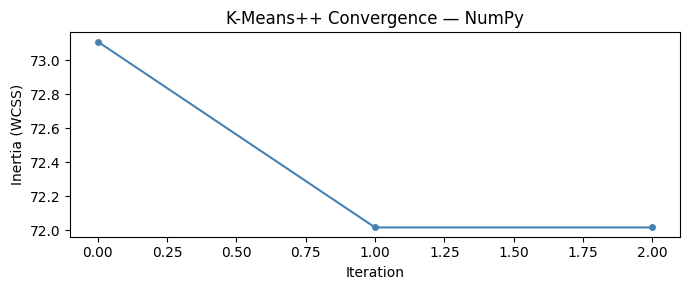

In [6]:
plt.figure(figsize=(7, 3))
plt.plot(inertia_history, marker='o', markersize=4, color='steelblue')
plt.xlabel('Iteration'); plt.ylabel('Inertia (WCSS)')
plt.title('K-Means++ Convergence — NumPy')
plt.tight_layout(); plt.show()

## 7. Cluster Visualisation

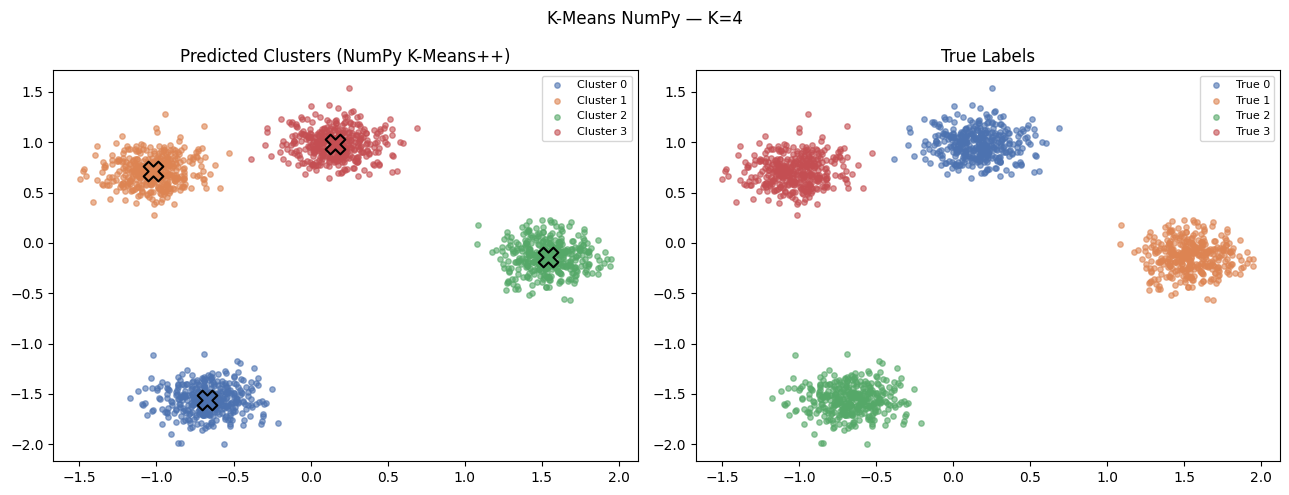

In [7]:
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for j in range(K):
    pts = X[labels == j]
    ax1.scatter(pts[:, 0], pts[:, 1], s=15, alpha=0.6, color=colors[j], label=f'Cluster {j}')
    ax1.scatter(*centroids[j], s=200, marker='X', color=colors[j], edgecolors='black', linewidths=1.5)
ax1.set_title('Predicted Clusters (NumPy K-Means++)')
ax1.legend(fontsize=8)

for j in range(K):
    pts = X[y_true == j]
    ax2.scatter(pts[:, 0], pts[:, 1], s=15, alpha=0.6, color=colors[j], label=f'True {j}')
ax2.set_title('True Labels')
ax2.legend(fontsize=8)

plt.suptitle('K-Means NumPy — K=4', fontsize=12)
plt.tight_layout(); plt.show()

## 8. Elbow Method

Vectorised — runs k=1..10 in seconds.

Iter   1 | Inertia: 3000.0000 | Max shift: 1.758378
Converged at iteration 2.
  k=1 | Inertia: 3000.00
Iter   1 | Inertia: 1706.3787 | Max shift: 1.187881
Converged at iteration 3.
  k=2 | Inertia: 1641.60
Iter   1 | Inertia: 371.0503 | Max shift: 0.727356
Converged at iteration 3.
  k=3 | Inertia: 347.99
Iter   1 | Inertia: 73.1109 | Max shift: 0.259281
Converged at iteration 3.
  k=4 | Inertia: 72.02
Iter   1 | Inertia: 67.9325 | Max shift: 0.287492
Iter   5 | Inertia: 65.5382 | Max shift: 0.007233
Iter  10 | Inertia: 65.4678 | Max shift: 0.004286
Converged at iteration 12.
  k=5 | Inertia: 65.46
Iter   1 | Inertia: 63.3570 | Max shift: 0.287492
Iter   5 | Inertia: 60.5791 | Max shift: 0.019709
Iter  10 | Inertia: 58.8105 | Max shift: 0.008839
Converged at iteration 12.
  k=6 | Inertia: 58.80
Iter   1 | Inertia: 57.2792 | Max shift: 0.287492
Iter   5 | Inertia: 54.0404 | Max shift: 0.019709
Iter  10 | Inertia: 52.2146 | Max shift: 0.008839
Iter  15 | Inertia: 52.1944 | Max shift: 0.0

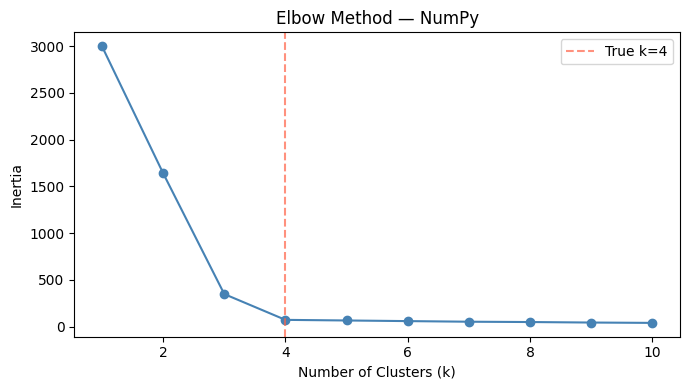

In [8]:
K_range  = range(1, 11)
inertias = []
for k in K_range:
    lbl, ctr, _, _ = kmeans(X, k=k, random_state=42)
    inertias.append(compute_inertia(X, lbl, ctr))
    print(f"  k={k} | Inertia: {inertias[-1]:.2f}")

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertias, marker='o', color='steelblue')
plt.axvline(4, linestyle='--', color='tomato', alpha=0.7, label='True k=4')
plt.xlabel('Number of Clusters (k)'); plt.ylabel('Inertia')
plt.title('Elbow Method — NumPy'); plt.legend()
plt.tight_layout(); plt.show()

## 9. Silhouette Analysis

Plots the silhouette coefficient for each sample, grouped by cluster.
All bars should be above the dashed mean line, and widths should be roughly equal.

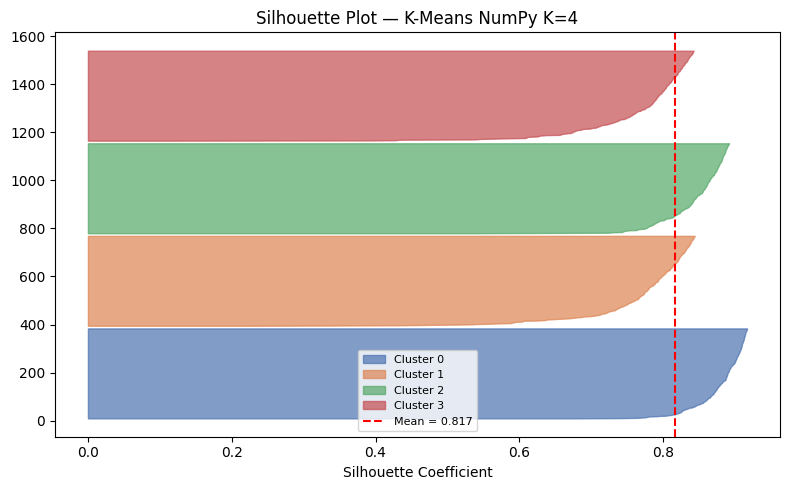

In [9]:
from sklearn.metrics import silhouette_samples, silhouette_score, davies_bouldin_score, calinski_harabasz_score

sil_vals = silhouette_samples(X, labels)
sil_avg  = sil_avg = silhouette_score(X, labels)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
for j in range(K):
    vals_j = np.sort(sil_vals[labels == j])
    size_j = len(vals_j)
    y_upper = y_lower + size_j
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_j,
                     alpha=0.7, color=colors[j], label=f'Cluster {j}')
    y_lower = y_upper + 10

ax.axvline(sil_avg, color='red', linestyle='--', label=f'Mean = {sil_avg:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_title('Silhouette Plot — K-Means NumPy K=4')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 10. Evaluation Metrics

In [10]:
sil = silhouette_score(X, labels)
dbs = davies_bouldin_score(X, labels)
chs = calinski_harabasz_score(X, labels)
inn = compute_inertia(X, labels, centroids)

print(f"Inertia (WCSS)          : {inn:.4f}  (lower = tighter clusters)")
print(f"Silhouette Score        : {sil:.4f}  (higher = better, range -1..1)")
print(f"Davies-Bouldin Score    : {dbs:.4f}  (lower = better)")
print(f"Calinski-Harabasz Score : {chs:.4f}  (higher = better)")
print(f"Iterations to converge  : {n_iter}")

Inertia (WCSS)          : 72.0156  (lower = tighter clusters)
Silhouette Score        : 0.8170  (higher = better, range -1..1)
Davies-Bouldin Score    : 0.2571  (lower = better)
Calinski-Harabasz Score : 20274.6064  (higher = better)
Iterations to converge  : 3


## 11. Random Init vs K-Means++ — Side-by-Side

Iter   1 | Inertia: 661.9637 | Max shift: 0.907315
Iter   5 | Inertia: 72.0156 | Max shift: 0.001841
Converged at iteration 6.
Iter   1 | Inertia: 72.0156 | Max shift: 0.374034
Converged at iteration 2.
Iter   1 | Inertia: 1207.1710 | Max shift: 1.459565
Converged at iteration 4.
Iter   1 | Inertia: 72.0156 | Max shift: 0.361759
Converged at iteration 2.
Iter   1 | Inertia: 812.0203 | Max shift: 1.263701
Converged at iteration 3.
Iter   1 | Inertia: 72.1206 | Max shift: 0.346243
Converged at iteration 3.
Iter   1 | Inertia: 465.1747 | Max shift: 0.562056
Iter   5 | Inertia: 342.1442 | Max shift: 0.021871
Iter  10 | Inertia: 341.5151 | Max shift: 0.010069
Iter  15 | Inertia: 341.3931 | Max shift: 0.002111
Iter  20 | Inertia: 341.3774 | Max shift: 0.002878
Iter  25 | Inertia: 341.3253 | Max shift: 0.003088
Converged at iteration 27.
Iter   1 | Inertia: 72.0156 | Max shift: 0.376443
Converged at iteration 2.
Iter   1 | Inertia: 1563.4107 | Max shift: 1.174692
Iter   5 | Inertia: 72.6471 |

/var/folders/ds/h1x47v9s101ft_h8ycw63j_80000gn/T/ipykernel_30837/123437349.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([random_inertias, pp_inertias], labels=['Random Init', 'K-Means++'], vert=False)


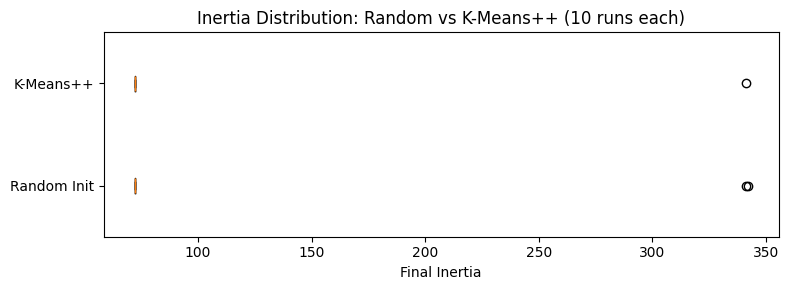

In [11]:
# Run both 10 times each and compare inertia distributions
n_runs = 10
random_inertias = []
pp_inertias     = []

for seed in range(n_runs):
    lbl_r, ctr_r, _, _ = kmeans(X, k=K, init='random',   random_state=seed)
    lbl_p, ctr_p, _, _ = kmeans(X, k=K, init='kmeans++', random_state=seed)
    random_inertias.append(compute_inertia(X, lbl_r, ctr_r))
    pp_inertias.append(compute_inertia(X, lbl_p, ctr_p))

print(f"Random Init  | Mean inertia: {np.mean(random_inertias):.2f}  Std: {np.std(random_inertias):.2f}")
print(f"K-Means++    | Mean inertia: {np.mean(pp_inertias):.2f}  Std: {np.std(pp_inertias):.2f}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.boxplot([random_inertias, pp_inertias], labels=['Random Init', 'K-Means++'], vert=False)
ax.set_xlabel('Final Inertia')
ax.set_title('Inertia Distribution: Random vs K-Means++ (10 runs each)')
plt.tight_layout(); plt.show()

## 12. Save Model to `../Models/`

In [12]:
save_path = '../Models/kmeans_numpy.npz'
np.savez_compressed(
    save_path,
    centroids = centroids,   # (k, d)
    x_mean    = X_mean,      # (d,) for inverse-transform / new data scaling
    x_std     = X_std,       # (d,)
    k         = np.array(K)
)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")

Saved → ../Models/kmeans_numpy.npz  (0.8 KB)
